# Prepping the Environment

In [4]:
import pickle
import tarfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from huggingface_hub import PyTorchModelHubMixin, notebook_login

# === Setup ===
notebook_login()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# === Download and Load Dataset ===
!wget -q "https://zenodo.org/records/18397070/files/RML2016.10a.tar.bz2" -O RML2016.10a.tar.bz2

with tarfile.open("RML2016.10a.tar.bz2", "r:bz2") as tar:
    tar.extractall()

with open("RML2016.10a_dict_optimized.pkl", "rb") as f:
    data_dict = pickle.load(f, encoding="latin1")

/tmp/ipykernel_1393/668665961.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [6]:
# === Prepare Data ===
modulation_types = sorted(list(set(k[0] for k in data_dict.keys())))
snr_levels = sorted(list(set(k[1] for k in data_dict.keys())))

print(f"Modulation types ({len(modulation_types)}): {modulation_types}")
print(f"SNR levels ({len(snr_levels)}): {snr_levels}")

X = []
Y = []
SNR = []

for (mod, snr), samples in data_dict.items():
    X.append(samples)
    Y.extend([modulation_types.index(mod)] * samples.shape[0])
    SNR.extend([snr] * samples.shape[0])

X = np.vstack(X)
Y = np.array(Y)
SNR = np.array(SNR)

print(f"Dataset shape: {X.shape} | Labels: {Y.shape} | SNR: {SNR.shape}")

Modulation types (11): ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR levels (20): [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Dataset shape: (220000, 2, 128) | Labels: (220000,) | SNR: (220000,)


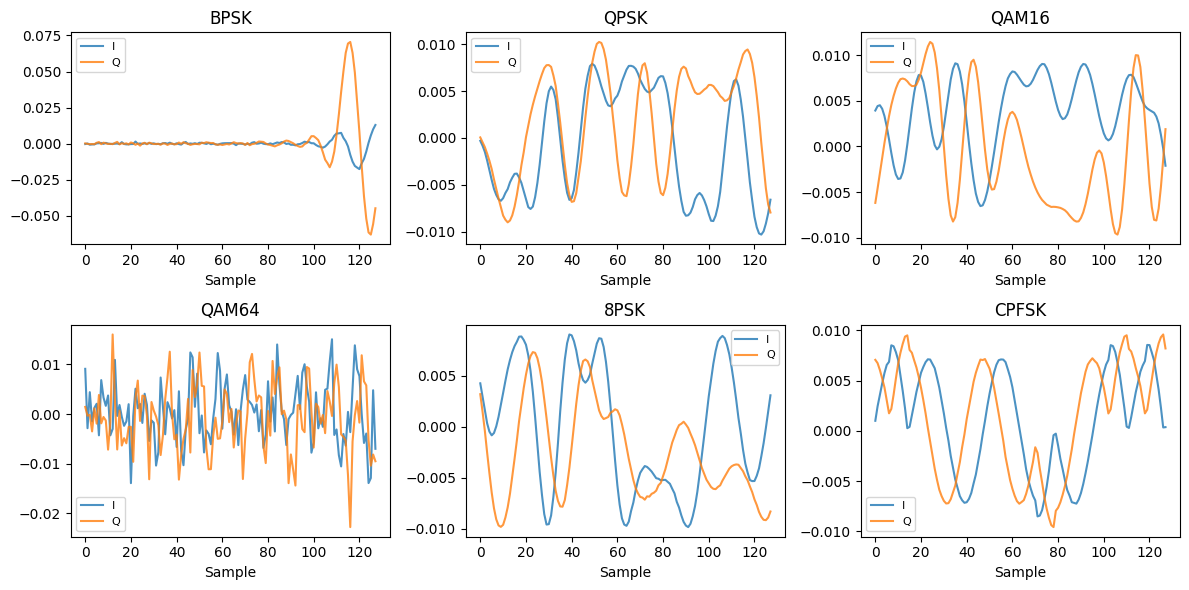

In [7]:
# === Visualize Signals ===
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
sample_mods = ["BPSK", "QPSK", "QAM16", "QAM64", "8PSK", "CPFSK"]

for ax, mod_name in zip(axes.flat, sample_mods):
    mod_idx = modulation_types.index(mod_name)
    high_snr_mask = (Y == mod_idx) & (SNR == 18)
    sample = X[high_snr_mask][0]
    ax.plot(sample[0], label="I", alpha=0.8)
    ax.plot(sample[1], label="Q", alpha=0.8)
    ax.set_title(mod_name)
    ax.legend(fontsize=8)
    ax.set_xlabel("Sample")

plt.tight_layout()
plt.savefig("signal_examples.png", dpi=100)
plt.show()

# Build and Train the 1D CNN Model

In [10]:
# === Train/Test Split ===
X_train, X_test, Y_train, Y_test, SNR_train, SNR_test = train_test_split(
    X, Y, SNR, test_size=0.2, stratify=Y, random_state=42
)

# Convert numpy arrays to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test, dtype=torch.long)

# Wrap tensors in Dataset and DataLoader for batched training
train_dataset = TensorDataset(X_train_t, Y_train_t)
test_dataset = TensorDataset(X_test_t, Y_test_t)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [11]:
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (176000, 2, 128) | Test: (44000, 2, 128)


In [12]:
# === Define Model ===
class ModulationClassifier(
    nn.Module,
    PyTorchModelHubMixin,
    library_name="modulation-classifier",
    pipeline_tag="tabular-classification",
    license="cc-by-nc-sa-4.0",
):
    def __init__(self, num_classes: int = 11, input_channels: int = 2, input_length: int = 128):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=8, padding="same")
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding="same")
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * (input_length // 4), 256)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x

In [13]:
# Create model instance and move to GPU
model = ModulationClassifier(num_classes=11, input_channels=2, input_length=128).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 1,093,835


In [14]:
# === Train ===
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
num_epochs = 30
losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_Y in train_loader:
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_X, batch_Y in test_loader:
                batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
                outputs = model(batch_X)
                _, predicted = torch.max(outputs, 1)
                total += batch_Y.size(0)
                correct += (predicted == batch_Y).sum().item()
        val_acc = correct / total
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv1d(


Epoch 5/30 | Loss: 1.6710 | Val Acc: 0.3967
Epoch 10/30 | Loss: 1.4534 | Val Acc: 0.4720
Epoch 15/30 | Loss: 1.3408 | Val Acc: 0.5053
Epoch 20/30 | Loss: 1.3072 | Val Acc: 0.5174
Epoch 25/30 | Loss: 1.2897 | Val Acc: 0.5070
Epoch 30/30 | Loss: 1.2767 | Val Acc: 0.5225


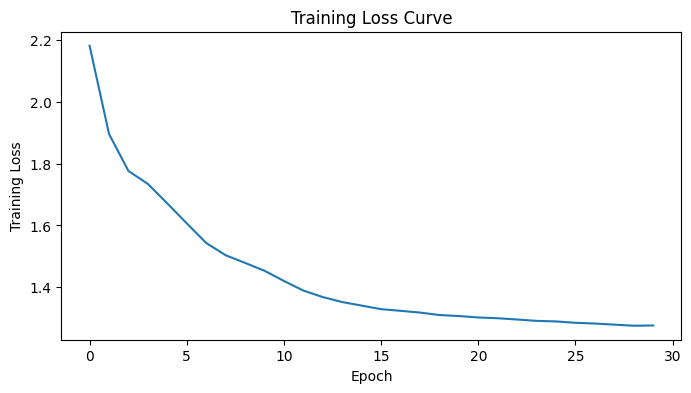

In [15]:
# Plot how the loss decreased over training
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.savefig("training_loss.png", dpi=100)
plt.show()

# Evaluate and Diagnose Model Perfomance

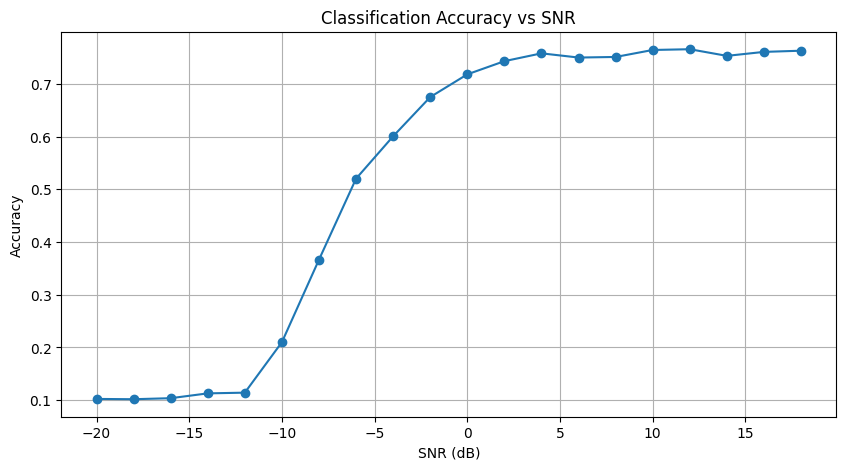

In [19]:
# === Evaluate Per-SNR ===
model.eval()
snr_accuracy = {}

for snr_val in snr_levels:
    mask = SNR_test == snr_val
    if mask.sum() == 0:
        continue
    X_snr = torch.tensor(X_test[mask], dtype=torch.float32).to(device)
    Y_snr = torch.tensor(Y_test[mask], dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(X_snr)
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == Y_snr).float().mean().item()
    snr_accuracy[snr_val] = acc

plt.figure(figsize=(10, 5))
plt.plot(list(snr_accuracy.keys()), list(snr_accuracy.values()), marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy vs SNR")
plt.grid(True)
plt.savefig("accuracy_vs_snr.png", dpi=100)
plt.show()

In [20]:
# High-SNR accuracy
high_snr_mask = SNR_test >= 0
X_high = torch.tensor(X_test[high_snr_mask], dtype=torch.float32).to(device)
Y_high = torch.tensor(Y_test[high_snr_mask], dtype=torch.long).to(device)

with torch.no_grad():
    outputs = model(X_high)
    _, predicted = torch.max(outputs, 1)
    high_snr_acc = (predicted == Y_high).float().mean().item()

overall_mask = np.ones(len(Y_test), dtype=bool)
X_all = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_all = torch.tensor(Y_test, dtype=torch.long).to(device)

with torch.no_grad():
    outputs = model(X_all)
    _, predicted_all = torch.max(outputs, 1)
    overall_acc = (predicted_all == Y_all).float().mean().item()

print(f"\nOverall test accuracy: {overall_acc:.4f}")
print(f"High-SNR (>= 0dB) accuracy: {high_snr_acc:.4f}")
print(f"Model parameters: {total_params:,}")


Overall test accuracy: 0.5225
High-SNR (>= 0dB) accuracy: 0.7526
Model parameters: 1,093,835


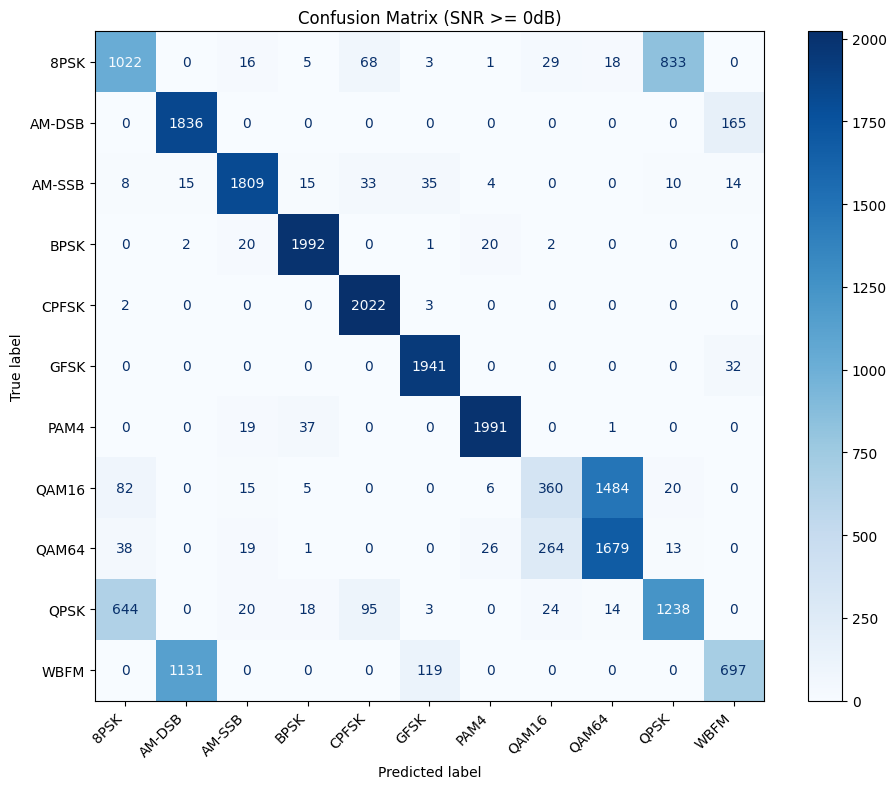

In [21]:
# Confusion matrix at high SNR
Y_high_np = Y_high.cpu().numpy()
predicted_np = predicted.cpu().numpy()

cm = confusion_matrix(Y_high_np, predicted_np)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modulation_types)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix (SNR >= 0dB)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()

# Deploy to Hugging Face and GitHub

In [22]:
# === Push to Hugging Face Hub ===
model.push_to_hub("tandrewu1/5G-Signal-Modulation-Classifier")
print("Model pushed to Hugging Face Hub!")

Model pushed to Hugging Face Hub!


In [23]:
# Verify reload
loaded_model = ModulationClassifier.from_pretrained("tandrewu1/5G-Signal-Modulation-Classifier")
print("Model loaded successfully from Hub!")

config.json:   0%|          | 0.00/69.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.38MB            

model.safetensors: downloading bytes:           |  0.00B            

Model loaded successfully from Hub!


In [24]:
# Generate a test sample to paste into the Space
test_idx = np.where((Y == modulation_types.index("QPSK")) & (SNR == 18))[0][0]
test_sample = X[test_idx]
print("I samples (copy this line):")
print(", ".join(f"{v:.6f}" for v in test_sample[0]))
print("\nQ samples (copy this line):")
print(", ".join(f"{v:.6f}" for v in test_sample[1]))

I samples (copy this line):
-0.000298, -0.000826, -0.001479, -0.002395, -0.003461, -0.004482, -0.005438, -0.006086, -0.006549, -0.006715, -0.006433, -0.005880, -0.005462, -0.004738, -0.004242, -0.003829, -0.003803, -0.004225, -0.004798, -0.005675, -0.006554, -0.007386, -0.007584, -0.007337, -0.006326, -0.004795, -0.002830, -0.000553, 0.001761, 0.003713, 0.004997, 0.005497, 0.005135, 0.004139, 0.002179, -0.000117, -0.002421, -0.004327, -0.005848, -0.006613, -0.006443, -0.005553, -0.003678, -0.001556, 0.000854, 0.003274, 0.005283, 0.006664, 0.007681, 0.007929, 0.007739, 0.007154, 0.006377, 0.005510, 0.004745, 0.003992, 0.003482, 0.003395, 0.003695, 0.004224, 0.004524, 0.005165, 0.006048, 0.006665, 0.007310, 0.007703, 0.007717, 0.007632, 0.007396, 0.006895, 0.006219, 0.005717, 0.005244, 0.004963, 0.004869, 0.005127, 0.005380, 0.005909, 0.006434, 0.006614, 0.006587, 0.005894, 0.004785, 0.003169, 0.001175, -0.001043, -0.003256, -0.005192, -0.006716, -0.007899, -0.008309, -0.008262, -0.00798